<a href="https://colab.research.google.com/github/CesarAr0504/Arredondo_Restrepo_Lab_Sen/blob/main/Practica_3_P1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Practica 3, analasis estadistico de seañales**



*   Cesar Eduardo Arredondo Gonzalez
*   Alejandro Restrepo Molina



###**1. Objetivos:**

**General:** Aplicar técnicas para el análisis de señales biomédicas en el dominio del tiempo mediante técnicas estadísticas.

**Específicos:**


*   Comprender las características que diferencian las señales determinísticas de las estocásticas.
*   Implementar diferentes técnicas para el análisis estadístico de señales, e interpretar los resultados
obtenidos.

###**2. Resumen:**
Esta práctica de laboratorio está diseñada para que apliquemos diversas técnicas estadísticas en el análisis de señales biomédicas dentro del dominio del tiempo, utilizando Python y sus librerias como herramienta principal para procesar los datos. El proceso comienza estableciendo una base teórica clara para diferenciar entre señales deterministas y estocásticas, entendiendo que la mayoría de las bioseñales son aleatorias por naturaleza y que su análisis depende de medir características como la media, la varianza y la estacionariedad a través del tiempo. En la fase práctica, primero implementaremos una función específica para obtener el valor cuadrático medio o RMS de las señales suministradas, lo cual es fundamental para cuantificar su magnitud. Luego, analizaremos registros de electrocardiografía comparando versiones filtradas y sin filtrar para entender el comportamiento de los filtros aplicados y extraer ciclos cardíacos individuales. Sobre estos ciclos, calcularemos métricas básicas de dispersión y realizaremos pruebas de hipótesis, como la prueba t o la prueba U de Mann-Whitney junto con el test de Dickey-Fuller, para determinar estadísticamente si las propiedades de la señal se mantienen constantes o si existen diferencias significativas entre distintos periodos de registro.

###**3. Marco teorico:**

Cuando trabajamos en el análisis de señales fisiologicas requerimos de un enfoque matemático robusto debido a la naturaleza (usualmente aleatoria) de los sistemas biológicos. A continuación, se describen los pilares teóricos aplicados para el desarrollo de esta práctica:

**3.1 Naturaleza de las Señales: Determinismo vs. Estocasticidad**

Las señales las podemos clasificar principalmente en 2 categorias:

*   **Deterministas:** Son aquellas que pueden describirse mediante una función matemática explícita y se reproducen exactamente bajo las mismas condiciones o dicho en palabras mas simples es posible conocer su valor en un tiempo determinado.

*   **Estocásticas (Aleatorias):** No se pueden predecir con exactitud y su comportamiento se describe mejor en términos de probabilidades y promedios. La mayoría de las bioseñales, como el ECG y el EEG, entran en esta categoría debido a la complejidad de las fuentes fisiológicas que las generan.

**3.2 Estacionariedad y Pruebas Estadísticas**

Una señal es estacionaria si sus propiedades estadísticas (como la media y la varianza) permanecen constantes a lo largo del tiempo. En la práctica, las bioseñales suelen ser no estacionarias debido a cambios en el estado del sujeto (estrés, movimiento, etc.). Para evaluar esto, utilizamos:



*   **Métricas de Dispersión:** El valor cuadrático medio (RMS) permite cuantificar la energía de la señal, mientras que la varianza y la desviación estándar miden qué tanto se alejan los datos de su valor promedio.

*   **Pruebas de Hipótesis:**

*   t-Student: Compara las medias de dos grupos para ver si hay diferencias significativas.

*   U de Mann-Whitney: Alternativa no paramétrica cuando los datos no siguen una distribución normal.

*   Test de Levene: Evalúa la homocedasticidad, es decir, si los grupos tienen varianzas similares.

*   Prueba de Dickey-Fuller (ADF): Un método formal para determinar estadísticamente si una serie de tiempo es estacionaria.

**3.4 Caracteristicas del ECG:**

El electrocardiograma (ECG) es el registro de la actividad eléctrica del corazón medida desde la superficie del cuerpo. Esta señal es de suma importancia en la bioingeniería clínica, ya que refleja los eventos fisiológicos de despolarización y repolarización del músculo cardíaco a lo largo del tiempo.

Un ciclo cardíaco normal en un ECG se compone de varias ondas y complejos principales, los cuales debes identificar al momento de segmentar la señal:

*   Onda P: Representa la despolarización (activación eléctrica) de las aurículas. Es una onda de baja amplitud y baja frecuencia.

*   Complejo QRS: Corresponde a la despolarización de los ventrículos. Debido a la gran masa muscular ventricular, este complejo presenta la mayor amplitud y contiene las componentes de más alta frecuencia de la señal. El pico R es el punto de referencia más utilizado para aislar ciclos individuales.

*   Onda T: Refleja la repolarización ventricular, es decir, la fase de recuperación eléctrica de los ventrículos..

**3.4 Librerias y funciones utilizadas:**

Para el desarrollo del procesamiento y análisis estadístico de la señal en esta práctica, se empleó las siguientes librerías y funciones principales:

NumPy (numpy): Librería fundamental para el manejo de arreglos y cálculos matemáticos. Se utilizaron funciones como np.sqrt y np.mean para el cálculo de la métrica RMS, y np.arange junto con np.shape para la creación del vector de tiempo y estructuración de los datos.

SciPy (scipy): Se utilizó para diversas tareas científicas y estadísticas:

*   scipy.io: Mediante la función sio.loadmat, permitió cargar y extraer los datos fisiológicos del archivo .mat (signals.mat).

*   scipy.signal: Se hizo uso de la función find_peaks para la identificación de los máximos locales, lo cual es esencial para encontrar los picos R y aislar los ciclos cardíacos individuales.

*   scipy.stats: Proporcionó las herramientas necesarias para efectuar las pruebas de hipótesis estadísticas detalladas en el marco teórico (como t-Student, U de Mann-Whitney y Levene).

Matplotlib (matplotlib.pyplot): Utilizada para la visualización gráfica de los datos en el dominio del tiempo. Funciones como plt.subplots, plot, grid, y los ajustes de ejes (set_xlabel, set_ylabel, set_title) permitieron graficar y comparar las señales del ECG (originales vs. filtradas).

Statsmodels (statsmodels.tsa.stattools): De esta librería se importó específicamente la función adfuller, la cual se encarga de ejecutar la prueba de Dickey-Fuller (ADF) para validar matemáticamente la estacionariedad de las señales temporales.

### **4. Practica:**










In [ ]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller

data = sio.loadmat('signals.mat')
print("Información del archivo .mat")
for key, value in data.items():
    if not key.startswith('__'):
        print(f"\n--- {key} ---")
        print("Tipo de dato:", type(value))
        print("Forma (Shape):", np.shape(value))
        #print("Contenido:\n", value)


Información del archivo .mat

--- Fs ---
Tipo de dato: <class 'numpy.ndarray'>
Forma (Shape): (1, 1)

--- ECG_asRecording ---
Tipo de dato: <class 'numpy.ndarray'>
Forma (Shape): (1, 30720)

--- ECG_filtered ---
Tipo de dato: <class 'numpy.ndarray'>
Forma (Shape): (1, 30720)

--- EMG_filtered1 ---
Tipo de dato: <class 'numpy.ndarray'>
Forma (Shape): (1, 30721)

--- EMG_filtered2 ---
Tipo de dato: <class 'numpy.ndarray'>
Forma (Shape): (1, 30721)

--- EMG_asRecording1 ---
Tipo de dato: <class 'numpy.ndarray'>
Forma (Shape): (1, 30721)

--- EMG_asRecording2 ---
Tipo de dato: <class 'numpy.ndarray'>
Forma (Shape): (1, 30721)


**4.1 Implementación de funcion RMS:**

La función RMS se define como:

$$\chi_{RMS}=\left[\frac{1}{N}\sum_{i=1}^{N}\chi(i)^{2}\right]^{\frac{1}{2}}$$

In [ ]:
def RMS(señal):
  RMS = np.sqrt(np.mean(señal**2))
  return RMS

**4.2 Analisis estadistico de ECG:**

**4.2.1 Determinar el tiempo de duración de las señales y crear un vector de tiempo:**

In [ ]:
numero_muestras=len(data['ECG_asRecording'][0])
fs=data["Fs"]
print(f"El tiempo de muestreo es: {numero_muestras/fs[0][0]} seg")
ts=1/fs
tiempo = np.arange(0,numero_muestras/fs,ts) #0 a 30 seg con 1024 Hz de Fs
len(tiempo)

El tiempo de muestreo es: 30.0 seg


/tmp/ipykernel_150/1491605269.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tiempo = np.arange(0,numero_muestras/fs,ts) #0 a 30 seg con 1024 Hz de Fs


30720

**4.2.2 Graficas de la señal sin filtrar y filtrada:**

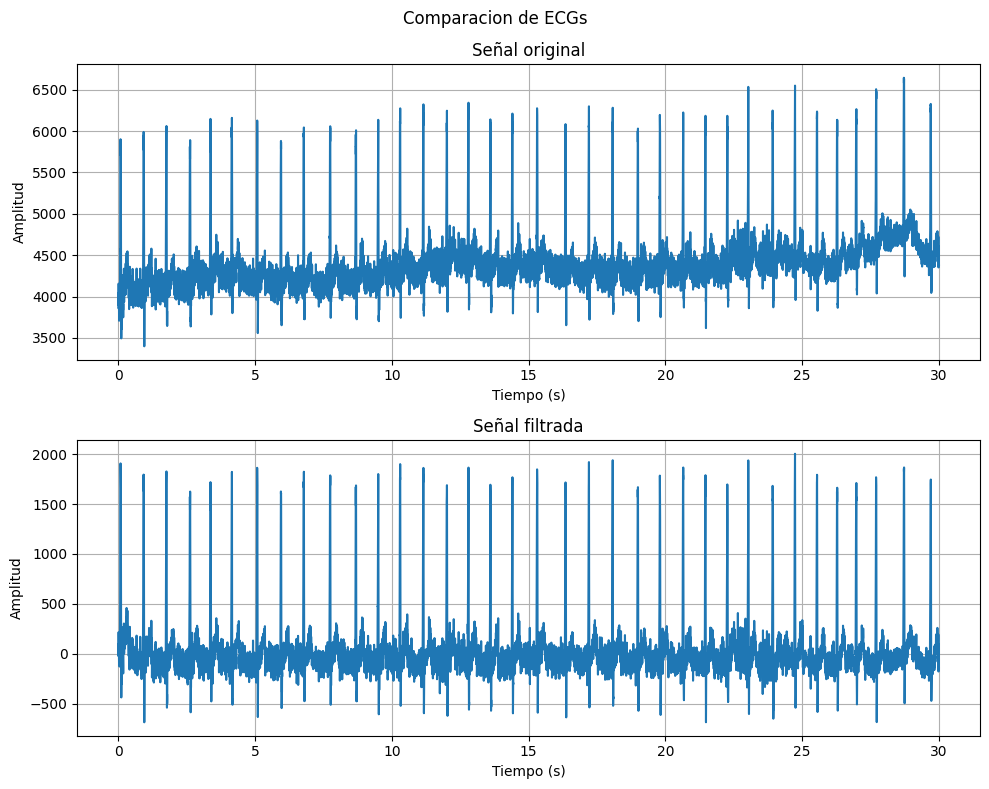

In [ ]:
fig,(ax1,ax2) = plt.subplots(2,1, figsize = (10,8))
fig.suptitle('Comparacion de ECGs')
ax1.plot(tiempo,data['ECG_asRecording'][0][:])
ax1.grid()
ax1.set_title("Señal original")
ax1.set_ylabel('Amplitud')
ax1.set_xlabel('Tiempo (s)')
ax2.plot(tiempo,data['ECG_filtered'][0][:])
ax2.grid()
ax2.set_title("Señal filtrada")
ax2.set_ylabel('Amplitud')
ax2.set_xlabel('Tiempo (s)')
fig.tight_layout()

**Observaciones:**

Se observa que la señal filtrada está centrada alrededor de 0, indicando que se eliminó la componente DC ya que en la señal original hay un offset de aprox 4-4.5 V

Los picos QRS (picos periodicos) siguen presentes, lo cual es bueno ya que indica que no se perdió información importante.

A simple vista los datos de la señal filtrada son más consistentes (menos variaciones), la original sube lentamente con el tiempo. probablemente gracias a la deriva de la linea base (bajas frecuencias).

El filtro que se usó debe de ser un **pasa banda**, ya que el ECG tiene ciertas frecuencias de interés como 0.5- 40 Hz, por debajo se encuentra la deriva de la linea base y por encima ruido electrico y muscular.

**4.2.3 Ciclo cardiaco de señal sin filtrar y
promedio, valor RMS, varianza y desviación estándar del ciclo:**

Tiempo de ciclo cardiaco: (s) 0.8447265625


/tmp/ipykernel_150/536632305.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  t=np.arange(tiempo[inicio_ciclo],tiempo[final_ciclo],ts)


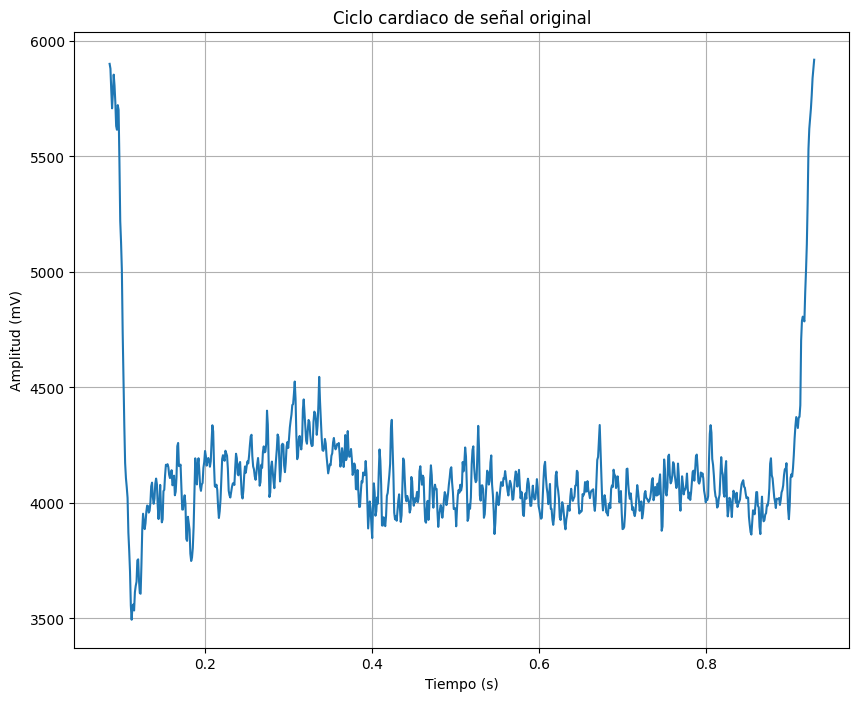

In [ ]:
indices_picos, _ = find_peaks(data['ECG_asRecording'][0][:], height=5000, distance=fs*0.6)
inicio_ciclo= indices_picos[0]
final_ciclo=indices_picos[1]
tiempo_ciclo=(indices_picos[1]-indices_picos[0])*1/fs[0][0]
print('Tiempo de ciclo cardiaco: (s)',tiempo_ciclo)
valores= data['ECG_asRecording'][0][inicio_ciclo:final_ciclo]
t=np.arange(tiempo[inicio_ciclo],tiempo[final_ciclo],ts)
plt.figure(figsize=(10,8))
plt.plot(t,valores)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (mV)")
plt.title("Ciclo cardiaco de señal original")
plt.grid()

In [ ]:
promedio=np.mean(valores)
rms=RMS(valores)
varianza=np.var(valores)
std=np.std(valores)
print(f'Estadísticas señal original:\n Promedio:{promedio}\n Valor RMS: {rms}\n Varianza: {varianza}\n Desviación estandar: {std}')

Estadísticas señal original:
 Promedio:4131.136266878161
 Valor RMS: 4142.454957820607
 Varianza: 93646.2220564969
 Desviación estandar: 306.01670225086883


**Observaciones:**

Al observar los datos del ciclo original, la primera impresión es que la señal está desplazada por un componente de offset muy alto, ya que el promedio de 4131.14 indica que el registro no parte de cero, sino que está montado sobre un nivel de voltaje constante. Esto se confirma al ver que el valor RMS es casi idéntico al promedio, lo que sugiere que la mayor parte de la energía detectada no es cardíaca, sino electrónica o estática. Por otro lado, la desviación estándar de 306.02 nos da una idea más real de la amplitud de los latidos, mostrando que la variación propia del corazón es pequeña comparada con el desplazamiento total. En resumen, aunque la gráfica muestra un ciclo limpio y reconocible, los estadísticos gritan que la señal necesita un filtrado urgente para eliminar ese pedestal de voltaje y poder analizar únicamente la actividad eléctrica del miocardio.

**4.2.4 Ciclo cardiaco de señal filtrada y
promedio, valor RMS, varianza y desviación estándar del ciclo:**


Tiempo de ciclo cardiaco: (s) 0.84375


/tmp/ipykernel_150/3284053827.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  t=np.arange(tiempo[inicio_ciclo],tiempo[final_ciclo],ts)


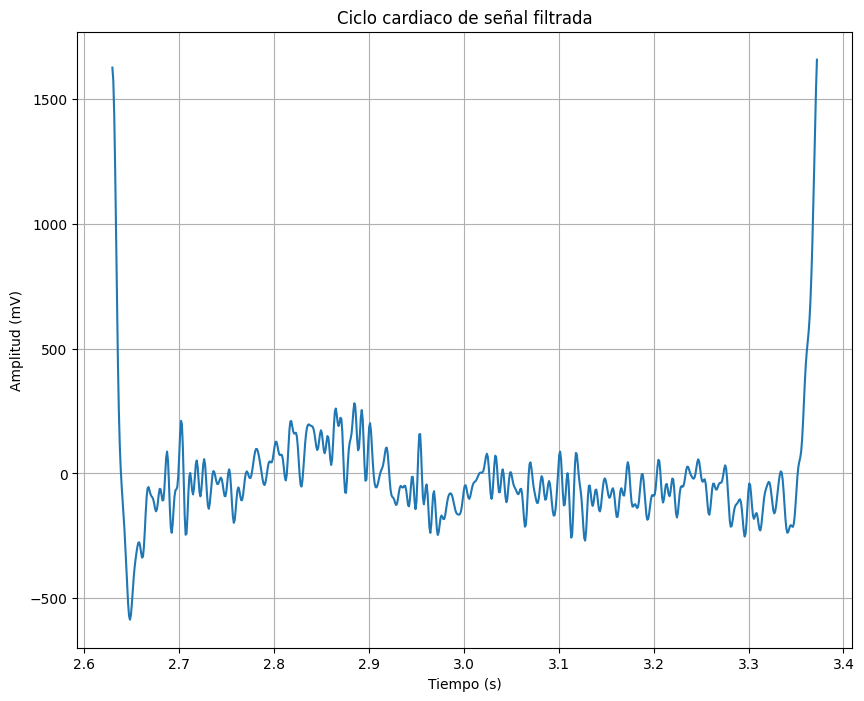

In [ ]:
indices_picos, _ = find_peaks(data['ECG_filtered'][0][:], height=1300, distance=fs*0.6)
inicio_ciclo= indices_picos[3]
final_ciclo=indices_picos[4]
tiempo_ciclo=(indices_picos[1]-indices_picos[0])*1/fs[0][0]
print('Tiempo de ciclo cardiaco: (s)',tiempo_ciclo)
valores= data['ECG_filtered'][0][inicio_ciclo:final_ciclo]
t=np.arange(tiempo[inicio_ciclo],tiempo[final_ciclo],ts)
plt.figure(figsize=(10,8))
plt.plot(t,valores)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (mV)")
plt.title("Ciclo cardiaco de señal filtrada")
plt.grid()

In [ ]:
promedio=np.mean(valores)
rms=RMS(valores)
varianza=np.var(valores)
std=np.std(valores)
print(f'Estadísticas señal filtrada:\n Promedio:{promedio}\n Valor RMS: {rms}\n Varianza: {varianza}\n Desviación estandar: {std}')


Estadísticas señal filtrada:
 Promedio:-20.975177997377532
 Valor RMS: 217.43729621701803
 Varianza: 46839.01969414558
 Desviación estandar: 216.4232420377848


**Observaciones:**

Al comparar ambos resultados (de la señal original y filtrada), la diferencia más drástica es la desaparición del offset. Mientras que la señal original tiene un promedio de 4131, la señal filtrada se ha centrado casi perfectamente, bajando a -20.97.

En cuanto a la energía, podemos ver cómo el RMS bajó de 4142 a solo 217. Esto demuestra que en la señal original, el valor RMS estaba distorsionado en cierto modo por el voltaje constante, mientras que en la filtrada, el RMS ahora sí representa la verdadera potencia de los latidos. Además, la desviación estándar también disminuyó (de 306 a 216), lo que indica que el filtro no solo centró la señal, sino que también eliminó ruidos de alta frecuencia que aumentaban artificialmente la variabilidad del ciclo.

**4.2.5 Extracción y graficas de 15 ciclos cardiacos de la señal filtrada con
promedio, y varianza:**

/tmp/ipykernel_150/556901135.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  t15.append(np.arange(tiempo[inicio_ciclo],tiempo[final_ciclo],ts))


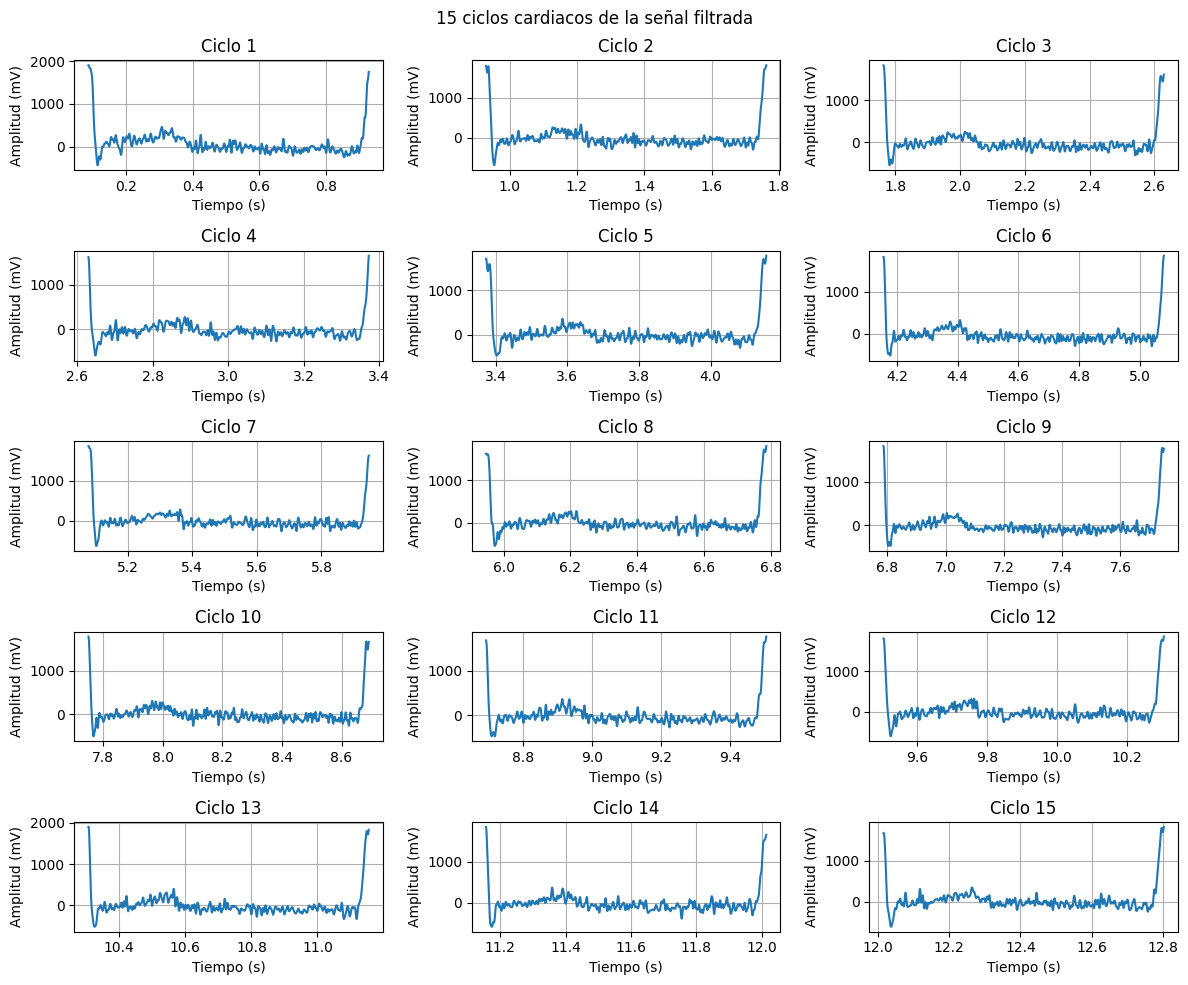

Estadísticas del ciclo 1:
 Promedio:74.00995782055861
 Varianza: 96684.31488232457
------------------------
Estadísticas del ciclo 2:
 Promedio:-1.4625781779933433
 Varianza: 104790.46548941819
------------------------
Estadísticas del ciclo 3:
 Promedio:-10.433000231133212
 Varianza: 82451.25107858983
------------------------
Estadísticas del ciclo 4:
 Promedio:-20.975177997377532
 Varianza: 46839.01969414558
------------------------
Estadísticas del ciclo 5:
 Promedio:40.87110478533409
 Varianza: 114850.02006450474
------------------------
Estadísticas del ciclo 6:
 Promedio:-27.94373421958412
 Varianza: 58147.589511512415
------------------------
Estadísticas del ciclo 7:
 Promedio:0.43078685936823324
 Varianza: 77707.28120177508
------------------------
Estadísticas del ciclo 8:
 Promedio:21.40785342744196
 Varianza: 100268.18152771876
------------------------
Estadísticas del ciclo 9:
 Promedio:-10.175289840749373
 Varianza: 71784.95578593282
------------------------
Estadísticas 

In [ ]:
t15 = []
v15 = []
plt.figure(figsize=(12, 10))
for i in range(15):
  inicio_ciclo= indices_picos[i]
  final_ciclo=indices_picos[i+1]
  v15.append(data['ECG_filtered'][0][inicio_ciclo:final_ciclo])
  t15.append(np.arange(tiempo[inicio_ciclo],tiempo[final_ciclo],ts))

  plt.subplot(5,3, i+1)
  plt.plot(t15[i], v15[i])
  plt.title(f"Ciclo {i+1}")
  plt.grid()
  plt.ylabel("Amplitud (mV)")
  plt.xlabel("Tiempo (s)")
plt.suptitle("15 ciclos cardiacos de la señal filtrada")
plt.tight_layout()
plt.show()

variaciones_promedio=[]
variaciones_var=[]
for i in range (15):
  promedio=np.mean(v15[i])
  varianza=np.var(v15[i])
  variaciones_promedio.append(promedio)
  variaciones_var.append(varianza)
  print(f'Estadísticas del ciclo {i+1}:\n Promedio:{promedio}\n Varianza: {varianza}\n------------------------')
print(f'Sigma de los promedios: {np.std(variaciones_promedio)}\n Sigma de la varianza: {np.std(variaciones_var)}')


**Observaciones y discusión**

El análisis gráfico de los 15 ciclos cardíacos muestra una alta repetibilidad en la morfología de la señal, evidenciada por la consistencia en la forma y amplitud del complejo QRS en cada ciclo. La duración de los ciclos es similar, lo que indica un ritmo cardíaco estable. Además, la línea base se mantiene relativamente constante, lo que confirma la correcta eliminación de la deriva mediante el filtrado. Aunque se observa un leve ruido residual, este no afecta significativamente la identificación de las características principales del ECG. En conjunto, la señal presenta un comportamiento periódico y estable, adecuado para análisis fisiológico.


En cuanto a su analisis estadístico se muestra que la media se mantiene cercana a cero con fluctuaciones moderadas, mientras que la varianza presenta variaciones pero sin una tendencia definida a lo largo del tiempo. Aunque existen diferencias entre ciclos, estas no son sistemáticas ni progresivas, lo que indica que las propiedades estadísticas de la señal se mantienen aproximadamente constantes. Por lo tanto, la señal puede considerarse débilmente estacionaria en el intervalo analizado.

**4.2.6 Analsis estadistico de estacionariedad :**

In [ ]:
ciclo_a = v15[0] # Ciclo 1
ciclo_b = v15[1] # Ciclo 2
_, p_norm_a = stats.shapiro(ciclo_a)
_, p_norm_b = stats.shapiro(ciclo_b)
_, p_levene = stats.levene(ciclo_a, ciclo_b)
print(f"--- Validación de Supuestos ---")
print(f"Normalidad p-values: Ciclo A={p_norm_a:.4f}, Ciclo B={p_norm_b:.4f}")
print(f"Homocedasticidad (Levene) p-value: {p_levene:.4f}\n")
if p_norm_a > 0.05 and p_norm_b > 0.05 and p_levene > 0.05:
    print("Se cumplen los supuestos. Realizando Prueba t de Student...")
    stat, p_val = stats.ttest_ind(ciclo_a, ciclo_b)
else:
    print("No se cumplen los supuestos. Realizando Prueba U de Mann-Whitney...")
    stat, p_val = stats.mannwhitneyu(ciclo_a, ciclo_b)

print(f"Resultado de la prueba: Estadístico={stat:.4f}, p-value={p_val:.4f}")

if p_val < 0.05:
    print("Conclusión: Existe una diferencia estadística significativa entre los ciclos.")
else:
    print("Conclusión: No existe diferencia estadística significativa (indica posible estacionariedad).")

--- Validación de Supuestos ---
Normalidad p-values: Ciclo A=0.0000, Ciclo B=0.0000
Homocedasticidad (Levene) p-value: 0.2240

No se cumplen los supuestos. Realizando Prueba U de Mann-Whitney...
Resultado de la prueba: Estadístico=478150.0000, p-value=0.0000
Conclusión: Existe una diferencia estadística significativa entre los ciclos.


**Observaciones y discusión**

Al procesar los datos de estos dos ciclos cardíacos, observamos que la señal de ECG rompe por completo con la estructura de una distribución normal, algo que se confirma con los p-values de 0.0000 en la prueba de Shapiro-Wilk. Los registros muestran que los voltajes se agrupan masivamente cerca de la línea base, pero los disparos de potencial del complejo QRS generan colas extremadamente largas que invalidan cualquier intento de tratarlos bajo una campana de Gauss.

Sin embargo, al ejecutar la prueba de Levene, detectamos un p-value de 0.2240, lo que nos indica que la dispersión de los datos es estable; es decir, aunque la forma de la distribución sea irregular, la amplitud se mantiene constante entre el primer y el segundo ciclo, descartando variaciones bruscas en la ganancia o ruido impulsivo repentino.  

Ante la falta de normalidad, se opto por la prueba U de Mann-Whitney, la cual nos entrega un estadístico de 478150.0000 y un p-value de 0.0000. Este resultado es contundente: existe una diferencia estadística significativa entre los dos ciclos. Esto representa que, aunque a simple vista los latidos parezcan gemelos, sus distribuciones de probabilidad no coinciden. Esto suele ocurrir porque hay pequeñas derivas en la línea base o variaciones milimétricas en la repolarización de la onda T que la estadística no perdona.

In [ ]:
ciclo_a = v15[6] # Ciclo 5
ciclo_b = v15[11] # Ciclo 10
_, p_norm_a = stats.shapiro(ciclo_a)
_, p_norm_b = stats.shapiro(ciclo_b)
_, p_levene = stats.levene(ciclo_a, ciclo_b)
print(f"--- Validación de Supuestos ---")
print(f"Normalidad p-values: Ciclo A={p_norm_a:.4f}, Ciclo B={p_norm_b:.4f}")
print(f"Homocedasticidad (Levene) p-value: {p_levene:.4f}\n")
if p_norm_a > 0.05 and p_norm_b > 0.05 and p_levene > 0.05:
    print("Se cumplen los supuestos. Realizando Prueba t de Student...")
    stat, p_val = stats.ttest_ind(ciclo_a, ciclo_b)
else:
    print("No se cumplen los supuestos. Realizando Prueba U de Mann-Whitney...")
    stat, p_val = stats.mannwhitneyu(ciclo_a, ciclo_b)
print(f"Resultado de la prueba: Estadístico={stat:.4f}, p-value={p_val:.4f}")
if p_val < 0.05:
    print("Conclusión: Existe una diferencia estadística significativa entre los ciclos.")
else:
    print("Conclusión: No existe diferencia estadística significativa (indica posible estacionariedad).")

--- Validación de Supuestos ---
Normalidad p-values: Ciclo A=0.0000, Ciclo B=0.0000
Homocedasticidad (Levene) p-value: 0.2254

No se cumplen los supuestos. Realizando Prueba U de Mann-Whitney...
Resultado de la prueba: Estadístico=357901.0000, p-value=0.4906
Conclusión: No existe diferencia estadística significativa (indica posible estacionariedad).


**Observaciones y discusión**

Al procesar los datos de estos dos nuevos ciclos cardíacos, observamos que la señal de ECG nuevamente rompe con la estructura de una distribución normal, confirmándose con p-values de 0.0000 en la prueba de Shapiro-Wilk.

Al ejecutar la prueba de Levene, detectamos un p-value de 0.2254, lo que nos indica que la dispersión de los datos se mantiene estable. Esto significa que la amplitud y el nivel de ruido de fondo son consistentes entre ambos ciclos.

Ante la falta de normalidad, se optó por la prueba U de Mann-Whitney, la cual nos entrega un estadístico de 357901.0000 y un p-value de 0.4906. Este resultado es fundamentalmente distinto al anterior: al ser el p-value mayor a 0.05, concluimos que no existe una diferencia estadística significativa entre los dos ciclos. Esto representa que, para este par de latidos, las distribuciones de probabilidad son prácticamente idénticas, lo que indica una alta estacionariedad en la señal. En términos fisiológicos, esto sugiere un periodo de gran estabilidad donde la morfología de la onda, el nivel de la línea base y la repolarización se han repetido con una precisión casi matemática.

**4.2.7 Prueba de Dickey-Fuller:**

In [ ]:
print(f"--- Prueba de Dickey-Fuller Aumentada ---")
result = adfuller(data['ECG_filtered'][0])
print(f'Estadístico ADF: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
if result[1] < 0.05:
    print("Rechazamos la hipótesis nula: La señal es estacionaria.")
else:
    print("No rechazamos la hipótesis nula: La señal NO es estacionaria.")

--- Prueba de Dickey-Fuller Aumentada ---
Estadístico ADF: -24.1341
p-value: 0.0000
Rechazamos la hipótesis nula: La señal es estacionaria.


**Observaciones y discusión**

Al realizar la prueba de Dickey-Fuller Aumentada (ADF) sobre la totalidad de la señal, observamos que el comportamiento temporal del ECG se consolida bajo un marco de estabilidad estadística, lo cual se confirma con un p-value de 0.0000. El estadístico ADF de -24.1341 es significativamente más negativo que los valores críticos habituales, lo que nos permite rechazar con total seguridad la hipótesis nula de la existencia de una raíz unitaria.

Esto representa que, a nivel global, la señal es estacionaria; es decir, sus propiedades estadísticas como la media y la varianza no varían en función del tiempo a lo largo del registro. Mientras que en los análisis previos de ciclos individuales podíamos encontrar pequeñas diferencias latido a latido, esta prueba técnica demuestra que la serie de tiempo completa tiene una tendencia a regresar siempre a su promedio, sin presentar un comportamiento errático o derivas permanentes que crezcan indefinidamente. En el contexto de un ECG filtrado, este resultado es un indicador excelente de calidad, ya que confirma que el procesamiento previo logró eliminar con éxito las interferencias de baja frecuencia y que el ritmo cardíaco analizado mantiene una estructura consistente y predecible.



### **5. Resultado mas importante:**

El resultado más importante de esta práctica es la confirmación estadística de que la señal de ECG procesada es globalmente estacionaria, lo cual fue demostrado concluyentemente mediante la prueba de Dickey-Fuller (ADF). Al obtener un estadístico ADF de -24.1341 y un p-value de 0.0000, se logró rechazar con total seguridad la hipótesis nula de la existencia de una raíz unitaria. Este hallazgo es fundamental, ya que demuestra que, a pesar de las pequeñas variaciones naturales que ocurren latido a latido en un sistema estocástico, las propiedades estadísticas de la serie de tiempo completa (como la media y la varianza) se mantienen estables y constantes. Esto valida que el procesamiento y filtrado previo fueron sumamente efectivos para eliminar derivas y ruidos de baja frecuencia, obteniendo una señal de alta calidad para su análisis.

### **6. Conclusiones:**

**6.1 Importancia del preprocesamiento en bioseñales:** La comparación entre la señal de ECG original y la filtrada evidenció que la eliminación de ruido y nivel de offset es un paso crítico. Sin un filtrado adecuado, las métricas estadísticas y de dispersión podrían arrojar resultados sesgados, mientras que el preprocesamiento garantiza que la energía cuantificada (RMS) y las varianzas reflejen verdaderamente el comportamiento fisiológico del corazón.

**6.2 Comportamiento estacionario dentro de la estocasticidad:** Aunque el electrocardiograma es una bioseñal de naturaleza estocástica que no se puede predecir con exactitud punto a punto, el análisis demostró que posee una fuerte estabilidad estadística a largo plazo. La validación matemática de su estacionariedad confirma que el ritmo cardíaco analizado mantiene una estructura consistente, tendiendo a regresar a su promedio sin presentar comportamientos erráticos prolongados.

**6.3 Robustez de las pruebas de hipótesis en el análisis en el tiempo:** La combinación de métricas descriptivas (como el RMS) con pruebas estadísticas formales (como los test de normalidad y la prueba de Dickey-Fuller) resultó ser un enfoque analítico muy robusto. Estas herramientas no solo permiten segmentar y caracterizar la magnitud de los ciclos cardíacos individuales, sino que proporcionan una validación cuantitativa innegable sobre la integridad, consistencia y calidad de toda la serie de tiempo.


### **7. Referencias:**

Documentación de Librerías y Herramientas Informáticas:

NumPy Developers. (2024). NumPy Documentation. Recuperado de: https://numpy.org/doc/stable/

SciPy Community. (2024). SciPy Reference Guide (Incluye documentación sobre scipy.signal, scipy.stats y scipy.io). Recuperado de: https://docs.scipy.org/doc/scipy/reference/

The Matplotlib Development Team. (2024). Matplotlib: Visualization with Python. Recuperado de: https://matplotlib.org/stable/users/index.html

Statsmodels Development Team. (2024). statsmodels.tsa.stattools.adfuller (Documentación oficial de la prueba de Dickey-Fuller aumentada). Recuperado de: https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html

Conceptos de Procesamiento de Señales y Estadística:

NIST/SEMATECH. (2012). e-Handbook of Statistical Methods (Recurso para pruebas de hipótesis, normalidad y estacionariedad). Recuperado de: https://www.itl.nist.gov/div898/handbook/

PhysioNet. (s.f.). The Research Resource for Complex Physiologic Signals (Base de datos y métodos de análisis de bioseñales como el ECG). Recuperado de: https://physionet.org/